In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
LOG_DIR = "/content/drive/MyDrive/user_study_logs"
OUT_DIR  = "/content/drive/MyDrive/user_study_logs"
METRICS  = ["percent_not_understood", "ave_num_tokens",
            "ave_hard_tokens", "percent_hard_tokens", "ave_percent_hard_tokens"]
SUMMARY_PATH = "/content/drive/MyDrive/user_study_logs/engine_level_summary.json"

# Wong, B. (2011) “Points of view: Color blindness,” Nature Methods 8:441. (Often called the “Wong” or “Okabe-Ito” palette.)
ENGINE_ORDER = ["baseline", "prompting", "overgen", "fudge"]
ENGINE_COLORS = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']
color_map = {eng: ENGINE_COLORS[i] for i, eng in enumerate(ENGINE_ORDER)}

In [ ]:
import os, json

def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def new_stats():
    return {
        "rounds": 0,
        "understood_false_cnt": 0,
        "sum_tokens_per_round": 0,
        "sum_hard_per_round": 0,
        "total_tokens": 0,
        "total_hard_tokens": 0,
        "sum_pct_hard_per_round": 0
    }

def add_round(stats, rnd):
    # TODO: get corelation between "understood" and (n_hard / n_tok) across all rounds for all engines
    understood = rnd.get("understood", False)
    n_tok  = len(rnd.get("student_tokens", [])) + len(rnd.get("tutor_tokens", []))
    n_hard = len(rnd.get("hard_tokens", []))
    stats["rounds"]               += 1
    stats["understood_false_cnt"] += int(not understood)
    stats["sum_tokens_per_round"] += n_tok
    stats["sum_hard_per_round"]   += n_hard
    stats["total_tokens"]         += n_tok
    stats["total_hard_tokens"]    += n_hard
    stats["sum_pct_hard_per_round"] += (n_hard / n_tok) if n_tok else 0

def finalize(raw):
    r  = max(raw["rounds"], 1)
    tt = max(raw["total_tokens"], 1)
    return {
        "percent_not_understood":  raw["understood_false_cnt"] / r,
        "ave_num_tokens":      raw["sum_tokens_per_round"] / r,
        "ave_hard_tokens":     raw["sum_hard_per_round"]  / r,
        "percent_hard_tokens": raw["total_hard_tokens"] / tt,
        "ave_percent_hard_tokens": raw["sum_pct_hard_per_round"] / r
    }



In [ ]:
engine_level_summary = {}
engine_round_summary = {}

for fname in os.listdir(LOG_DIR):
    if not fname.endswith(".json"):
        continue
    data   = read_json(os.path.join(LOG_DIR, fname))
    engine = data.get("engine", "unknown")
    level  = data.get("level",  "unknown").lower()


    eng_lvl = engine_level_summary.setdefault(
        engine,
        {"error_cnt_major": 0, "error_cnt_minor": 0, "_TOTAL": new_stats()},
    )
    eng_lvl.setdefault(level, new_stats())


    eng_rnd = engine_round_summary.setdefault(engine, {})

    for rnd in data.get("script", []):
        err = rnd.get("error", "").lower()
        if err == "major":
            eng_lvl["error_cnt_major"] += 1
            continue
        if err == "minor":
            eng_lvl["error_cnt_minor"] += 1


        add_round(eng_lvl[level], rnd)
        add_round(eng_lvl["_TOTAL"], rnd)


        round_no = rnd.get("round")
        if round_no is None:
            continue
        stats = eng_rnd.setdefault(round_no, new_stats())
        add_round(stats, rnd)


for eng_dict in engine_level_summary.values():
    for key, raw in list(eng_dict.items()):
        if isinstance(raw, dict) and "rounds" in raw:
            eng_dict[key] = finalize(raw)

for eng, rounds in engine_round_summary.items():
    for r_no, raw in rounds.items():
        rounds[r_no] = finalize(raw)

# -------------------------------------------------------------
#  Pretty-print
# -------------------------------------------------------------
print("=== ENGINE / LEVEL SUMMARY ===")
print(json.dumps(engine_level_summary, ensure_ascii=False, indent=2))

print("\n=== ENGINE / ROUND SUMMARY ===")
print(json.dumps(engine_round_summary, ensure_ascii=False, indent=2))

=== ENGINE / LEVEL SUMMARY ===
{
  "prompting": {
    "error_cnt_major": 0,
    "error_cnt_minor": 0,
    "_TOTAL": {
      "percent_not_understood": 0.4166666666666667,
      "ave_num_tokens": 62.583333333333336,
      "ave_hard_tokens": 9.583333333333334,
      "percent_hard_tokens": 0.15312916111850866,
      "ave_percent_hard_tokens": 0.11032126690432265
    },
    "n5": {
      "percent_not_understood": 0.3333333333333333,
      "ave_num_tokens": 40.666666666666664,
      "ave_hard_tokens": 4.5,
      "percent_hard_tokens": 0.11065573770491803,
      "ave_percent_hard_tokens": 0.10035979380605452
    },
    "n4": {
      "percent_not_understood": 0.8333333333333334,
      "ave_num_tokens": 131.5,
      "ave_hard_tokens": 32.5,
      "percent_hard_tokens": 0.24714828897338403,
      "ave_percent_hard_tokens": 0.20394903625218944
    },
    "n3": {
      "percent_not_understood": 0.3333333333333333,
      "ave_num_tokens": 81.33333333333333,
      "ave_hard_tokens": 7.0,
      "perc

In [ ]:
import os, json
import numpy as np
from collections import defaultdict

LOG_DIR = "/content/drive/MyDrive/user_study_logs"
OUT_DIR = "/content/drive/MyDrive/user_study_logs"
METRICS  = ["percent_not_understood", "ave_num_tokens",
            "ave_hard_tokens", "percent_hard_tokens", "ave_percent_hard_tokens"]
SUMMARY_PATH = "/content/drive/MyDrive/user_study_logs/engine_level_summary.json"

ENGINE_ORDER = ["baseline", "prompting", "overgen", "fudge"]
ENGINE_COLORS = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']
color_map = {eng: ENGINE_COLORS[i] for i, eng in enumerate(ENGINE_ORDER)}

def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def new_stats():
    return {
        "rounds": 0,
        "understood_false_cnt": 0,
        "sum_tokens_per_round": 0,
        "sum_hard_per_round": 0,
        "total_tokens": 0,
        "total_hard_tokens": 0,
        "sum_pct_hard_per_round": 0
    }

def add_round(stats, rnd):
    understood = rnd.get("understood", False)
    n_tok  = len(rnd.get("student_tokens", [])) + len(rnd.get("tutor_tokens", []))
    n_hard = len(rnd.get("hard_tokens", []))
    stats["rounds"]               += 1
    stats["understood_false_cnt"] += int(not understood)
    stats["sum_tokens_per_round"] += n_tok
    stats["sum_hard_per_round"]   += n_hard
    stats["total_tokens"]         += n_tok
    stats["total_hard_tokens"]    += n_hard
    stats["sum_pct_hard_per_round"] += (n_hard / n_tok) if n_tok else 0

def finalize(raw):
    r  = max(raw["rounds"], 1)
    tt = max(raw["total_tokens"], 1)
    return {
        "percent_not_understood":  raw["understood_false_cnt"] / r,
        "ave_num_tokens":      raw["sum_tokens_per_round"] / r,
        "ave_hard_tokens":     raw["sum_hard_per_round"]  / r,
        "percent_hard_tokens": raw["total_hard_tokens"] / tt,
        "ave_percent_hard_tokens": raw["sum_pct_hard_per_round"] / r
    }

engine_level_summary = {}
engine_round_summary = {}

# NEW: collect per-engine lists of (understood_flag, hard_ratio)
corr_data = defaultdict(lambda: {"understood": [], "ratio": []})

for fname in os.listdir(LOG_DIR):
    if not fname.endswith(".json"):
        continue
    data   = read_json(os.path.join(LOG_DIR, fname))
    engine = data.get("engine", "unknown")
    level  = data.get("level",  "unknown").lower()

    eng_lvl = engine_level_summary.setdefault(
        engine,
        {"error_cnt_major": 0, "error_cnt_minor": 0, "_TOTAL": new_stats()},
    )
    eng_lvl.setdefault(level, new_stats())

    eng_rnd = engine_round_summary.setdefault(engine, {})

    for rnd in data.get("script", []):
        err = rnd.get("error", "").lower()
        if err == "major":
            eng_lvl["error_cnt_major"] += 1
            continue
        if err == "minor":
            eng_lvl["error_cnt_minor"] += 1
            continue

        # compute per-utterance ratio and record for correlation
        understood_flag = 1 if rnd.get("understood", False) else 0
        n_tok  = len(rnd.get("student_tokens", [])) + len(rnd.get("tutor_tokens", []))
        n_hard = len(rnd.get("hard_tokens", []))
        ratio  = (n_hard / n_tok) if n_tok else 0
        corr_data[engine]["understood"].append(understood_flag)
        corr_data[engine]["ratio"].append(ratio)

        # accumulate stats
        add_round(eng_lvl[level], rnd)
        add_round(eng_lvl["_TOTAL"], rnd)

        round_no = rnd.get("round")
        if round_no is None:
            continue
        stats = eng_rnd.setdefault(round_no, new_stats())
        add_round(stats, rnd)

# finalize stats
for eng_dict in engine_level_summary.values():
    for key, raw in list(eng_dict.items()):
        if isinstance(raw, dict) and "rounds" in raw:
            eng_dict[key] = finalize(raw)

for eng, rounds in engine_round_summary.items():
    for r_no, raw in rounds.items():
        rounds[r_no] = finalize(raw)

# PRINT correlations
print("\n=== UNDERSTOOD vs HARD-TOKEN RATIO CORRELATIONS ===")
for eng, data in corr_data.items():
    if len(data["understood"]) > 1:
        corr = np.corrcoef(data["understood"], data["ratio"])[0,1]
        print(f"{eng:10s}: corr(understood, hard_ratio) = {corr:.3f}")
    else:
        print(f"{eng:10s}: not enough data to compute correlation")

# pretty-print summaries
print("\n=== ENGINE / LEVEL SUMMARY ===")
print(json.dumps(engine_level_summary, ensure_ascii=False, indent=2))

print("\n=== ENGINE / ROUND SUMMARY ===")
print(json.dumps(engine_round_summary, ensure_ascii=False, indent=2))



=== UNDERSTOOD vs HARD-TOKEN RATIO CORRELATIONS ===
prompting : corr(understood, hard_ratio) = -0.827
baseline  : corr(understood, hard_ratio) = -0.679
fudge     : corr(understood, hard_ratio) = -0.755
overgen   : corr(understood, hard_ratio) = -0.778

=== ENGINE / LEVEL SUMMARY ===
{
  "prompting": {
    "error_cnt_major": 0,
    "error_cnt_minor": 0,
    "_TOTAL": {
      "percent_not_understood": 0.4166666666666667,
      "ave_num_tokens": 62.583333333333336,
      "ave_hard_tokens": 9.583333333333334,
      "percent_hard_tokens": 0.15312916111850866,
      "ave_percent_hard_tokens": 0.11032126690432265
    },
    "n5": {
      "percent_not_understood": 0.3333333333333333,
      "ave_num_tokens": 40.666666666666664,
      "ave_hard_tokens": 4.5,
      "percent_hard_tokens": 0.11065573770491803,
      "ave_percent_hard_tokens": 0.10035979380605452
    },
    "n4": {
      "percent_not_understood": 0.8333333333333334,
      "ave_num_tokens": 131.5,
      "ave_hard_tokens": 32.5,
    

In [ ]:
#!/usr/bin/env python3
import os
import json
import numpy as np

LOG_DIR       = "/content/drive/MyDrive/user_study_logs"
OUT_DIR       = "/content/drive/MyDrive/user_study_logs"
METRICS       = ["percent_not_understood", "ave_num_tokens",
                 "ave_hard_tokens", "percent_hard_tokens", "ave_percent_hard_tokens"]
SUMMARY_PATH  = os.path.join(LOG_DIR, "engine_level_summary.json")

# Palette from Wong & Okabe–Ito
ENGINE_ORDER  = ["baseline", "prompting", "overgen", "fudge"]
ENGINE_COLORS = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']
color_map     = {eng: ENGINE_COLORS[i] for i, eng in enumerate(ENGINE_ORDER)}

def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def new_stats():
    return {
        "rounds": 0,
        "understood_false_cnt": 0,
        "sum_tokens_per_round": 0,
        "sum_hard_per_round": 0,
        "total_tokens": 0,
        "total_hard_tokens": 0,
        "sum_pct_hard_per_round": 0
    }

def add_round(stats, rnd):
    """Accumulate counts for one round into stats dict."""
    understood = rnd.get("understood", False)
    n_tok      = len(rnd.get("student_tokens", [])) + len(rnd.get("tutor_tokens", []))
    n_hard     = len(rnd.get("hard_tokens", []))
    stats["rounds"]               += 1
    stats["understood_false_cnt"] += int(not understood)
    stats["sum_tokens_per_round"] += n_tok
    stats["sum_hard_per_round"]   += n_hard
    stats["total_tokens"]         += n_tok
    stats["total_hard_tokens"]    += n_hard
    stats["sum_pct_hard_per_round"] += (n_hard / n_tok) if n_tok else 0

def finalize(raw):
    """Convert raw counts into rates and averages."""
    r  = max(raw["rounds"], 1)
    tt = max(raw["total_tokens"], 1)
    return {
        "percent_not_understood":  raw["understood_false_cnt"] / r,
        "ave_num_tokens":          raw["sum_tokens_per_round"] / r,
        "ave_hard_tokens":         raw["sum_hard_per_round"]  / r,
        "percent_hard_tokens":     raw["total_hard_tokens"] / tt,
        "ave_percent_hard_tokens": raw["sum_pct_hard_per_round"] / r
    }

# -------------------------------------------------------------------
# 1.  Aggregate summaries and collect correlation data globally
# -------------------------------------------------------------------
all_understood = []
all_ratio      = []

engine_level_summary = {}
engine_round_summary = {}

for fname in os.listdir(LOG_DIR):
    if not fname.endswith(".json"):
        continue
    data   = read_json(os.path.join(LOG_DIR, fname))
    engine = data.get("engine", "unknown")
    level  = data.get("level",  "unknown").lower()

    # per-engine, per-level containers
    eng_lvl = engine_level_summary.setdefault(
        engine,
        {"error_cnt_major": 0, "error_cnt_minor": 0, "_TOTAL": new_stats()}
    )
    eng_lvl.setdefault(level, new_stats())
    eng_rnd = engine_round_summary.setdefault(engine, {})

    for rnd in data.get("script", []):
        err = rnd.get("error", "").lower()
        if err == "major":
            eng_lvl["error_cnt_major"] += 1
            continue
        if err == "minor":
            eng_lvl["error_cnt_minor"] += 1

        # --- compute for correlation ---
        understood_flag = 1 if rnd.get("understood", False) else 0
        n_tok  = len(rnd.get("student_tokens", [])) + len(rnd.get("tutor_tokens", []))
        n_hard = len(rnd.get("hard_tokens", []))
        ratio  = (n_hard / n_tok) if n_tok else 0
        all_understood.append(understood_flag)
        all_ratio.append(ratio)
        # -------------------------------

        # accumulate into our summary stats
        add_round(eng_lvl[level], rnd)
        add_round(eng_lvl["_TOTAL"], rnd)

        round_no = rnd.get("round")
        if round_no is not None:
            stats = eng_rnd.setdefault(round_no, new_stats())
            add_round(stats, rnd)

# finalize per-engine summaries
for eng_dict in engine_level_summary.values():
    for key, raw in list(eng_dict.items()):
        if isinstance(raw, dict) and "rounds" in raw:
            eng_dict[key] = finalize(raw)
for eng, rounds in engine_round_summary.items():
    for r_no, raw in rounds.items():
        rounds[r_no] = finalize(raw)

# -------------------------------------------------------------------
# 2.  Output summaries and global correlation
# -------------------------------------------------------------------
print("=== ENGINE / LEVEL SUMMARY ===")
print(json.dumps(engine_level_summary, ensure_ascii=False, indent=2))

print("\n=== ENGINE / ROUND SUMMARY ===")
print(json.dumps(engine_round_summary, ensure_ascii=False, indent=2))

# global Pearson correlation
if len(all_understood) > 1:
    corr = np.corrcoef(all_understood, all_ratio)[0,1]
    print(f"\n=== GLOBAL corr(understood, hard_ratio) = {corr:.3f} ===")
else:
    print("\n=== Not enough data to compute global correlation ===")


=== ENGINE / LEVEL SUMMARY ===
{
  "prompting": {
    "error_cnt_major": 0,
    "error_cnt_minor": 0,
    "_TOTAL": {
      "percent_not_understood": 0.4166666666666667,
      "ave_num_tokens": 62.583333333333336,
      "ave_hard_tokens": 9.583333333333334,
      "percent_hard_tokens": 0.15312916111850866,
      "ave_percent_hard_tokens": 0.11032126690432265
    },
    "n5": {
      "percent_not_understood": 0.3333333333333333,
      "ave_num_tokens": 40.666666666666664,
      "ave_hard_tokens": 4.5,
      "percent_hard_tokens": 0.11065573770491803,
      "ave_percent_hard_tokens": 0.10035979380605452
    },
    "n4": {
      "percent_not_understood": 0.8333333333333334,
      "ave_num_tokens": 131.5,
      "ave_hard_tokens": 32.5,
      "percent_hard_tokens": 0.24714828897338403,
      "ave_percent_hard_tokens": 0.20394903625218944
    },
    "n3": {
      "percent_not_understood": 0.3333333333333333,
      "ave_num_tokens": 81.33333333333333,
      "ave_hard_tokens": 7.0,
      "perc

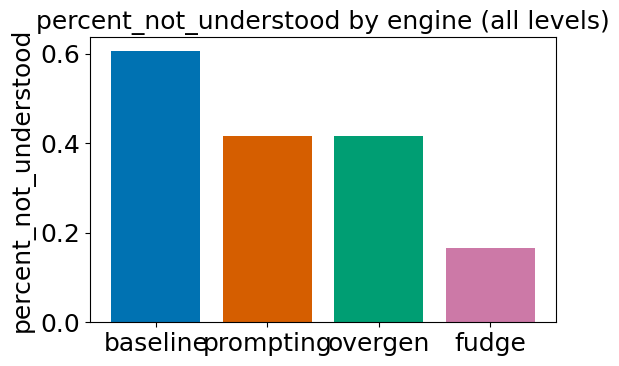

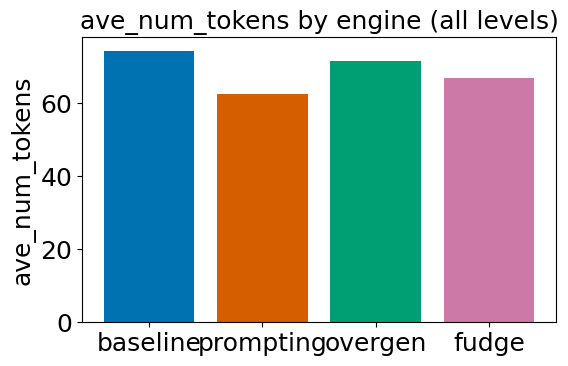

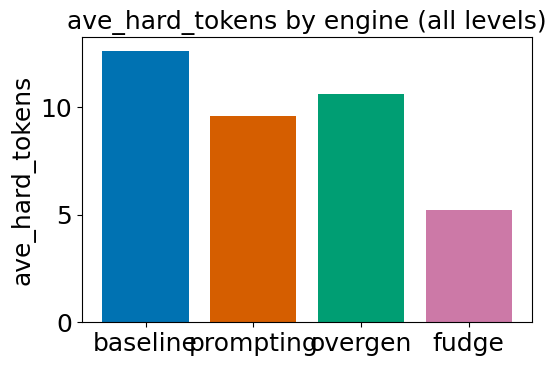

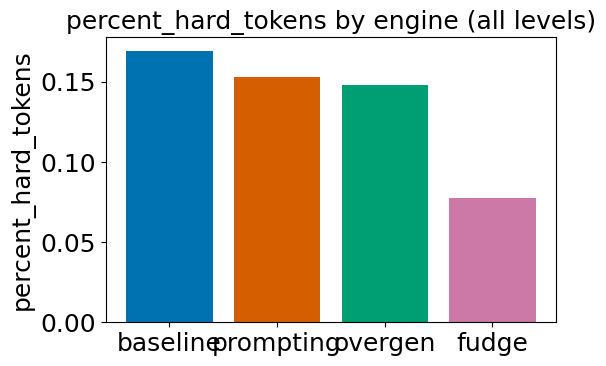

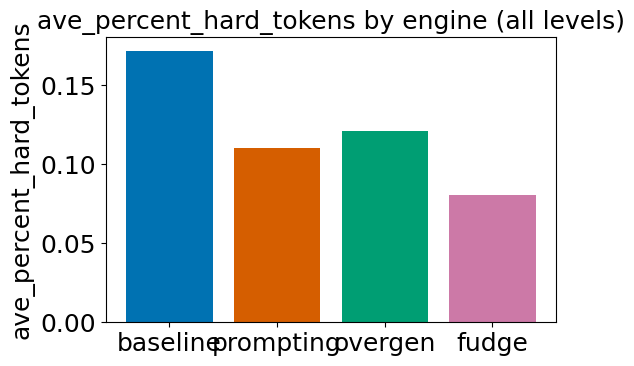

In [ ]:
import os, json, matplotlib.pyplot as plt

if "engine_level_summary" not in globals():
    with open(SUMMARY_PATH, encoding="utf-8") as f:
        engine_level_summary = json.load(f)

for metric in METRICS:
    engines = [e for e in ENGINE_ORDER if e in engine_level_summary]
    values  = [engine_level_summary[e]["_TOTAL"][metric] for e in engines]

    plt.figure(figsize=(6, 4))
    plt.bar(engines, values, color=[color_map[e] for e in engines])
    plt.ylabel(metric)
    plt.title(f"{metric} by engine (all levels)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{metric}_by_engine.png"), dpi=300)
    plt.show()



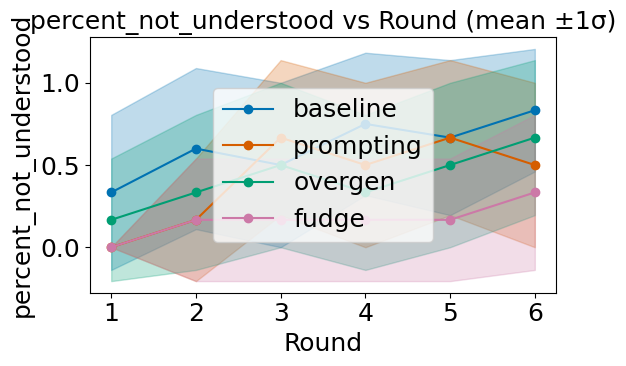

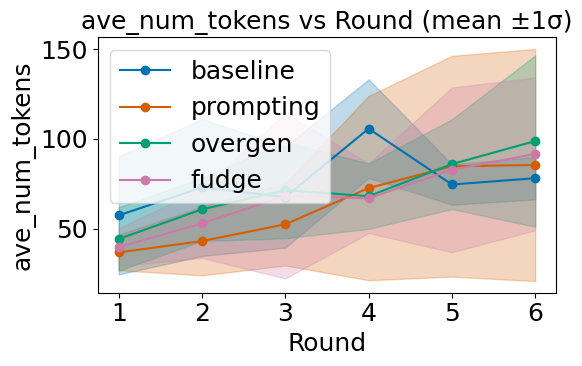

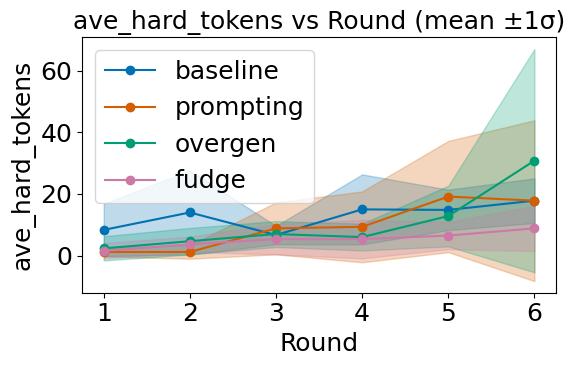

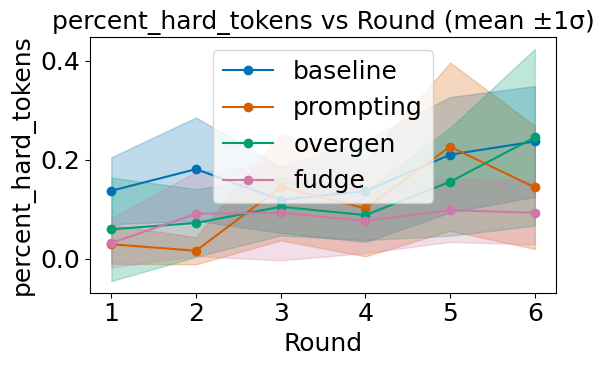

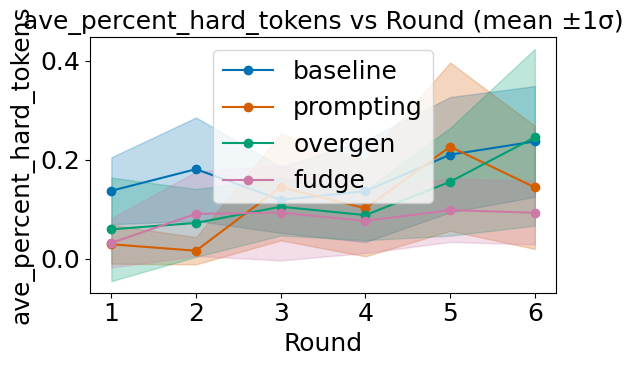

In [ ]:
# Mean ± 1σ
import os, json, numpy as np, matplotlib.pyplot as plt

round_values = {}

for file in os.listdir(LOG_DIR):
    if not file.endswith(".json"):
        continue
    data    = json.load(open(os.path.join(LOG_DIR, file), encoding="utf-8"))
    engine  = data.get("engine", "unknown")

    for rnd in data.get("script", []):
        if rnd.get("error", "").lower() == "major":
            continue
        r_no = rnd.get("round")
        if r_no is None:
            continue

        # base values
        understood = rnd.get("understood", False)
        tot_tokens = len(rnd.get("student_tokens", [])) + len(rnd.get("tutor_tokens", []))
        hard_tokens = len(rnd.get("hard_tokens", []))

        metric_vals = {
            "percent_not_understood": 0 if understood else 1,
            "ave_num_tokens": tot_tokens,
            "ave_hard_tokens": hard_tokens,
            "percent_hard_tokens": hard_tokens / tot_tokens if tot_tokens else 0,
            "ave_percent_hard_tokens": hard_tokens / tot_tokens if tot_tokens else 0
        }

        eng_dict = round_values.setdefault(engine, {})
        for m, v in metric_vals.items():
            eng_m = eng_dict.setdefault(m, {})
            eng_r = eng_m.setdefault(r_no, [])
            eng_r.append(v)

# all rounds present across engines
ROUNDS = sorted({r for eng in round_values.values()
                   for m in eng.values()
                   for r in m})


for metric in METRICS:
    plt.figure(figsize=(6, 4))
    for eng, col in color_map.items():
        r_means, r_stds = [], []
        for r in ROUNDS:
            vals = round_values.get(eng, {}).get(metric, {}).get(r, [])
            if vals:
                r_means.append(np.mean(vals))
                r_stds.append(np.std(vals))
            else:
                r_means.append(np.nan)
                r_stds.append(0)

        plt.plot(ROUNDS, r_means, marker="o", color=col, label=eng)
        # shaded ±1σ
        means = np.array(r_means)
        stds  = np.array(r_stds)
        plt.fill_between(ROUNDS,
                         means-stds, means+stds,
                         color=col, alpha=0.25)

    plt.xlabel("Round")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Round (mean ±1σ)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{metric}_by_round.png"), dpi=300)
    plt.show()



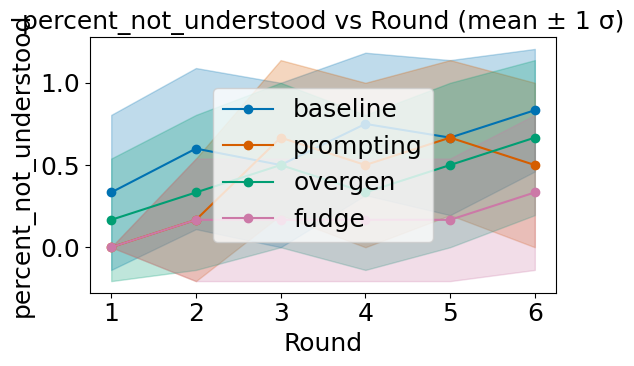

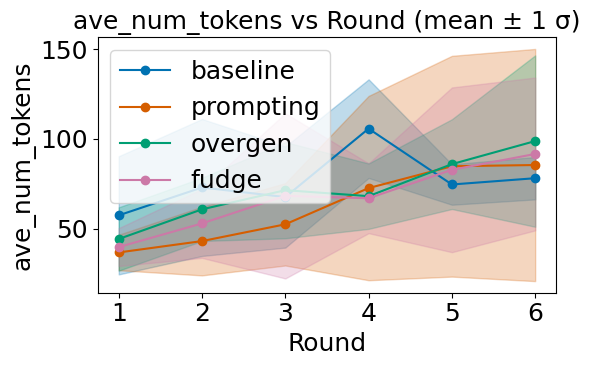

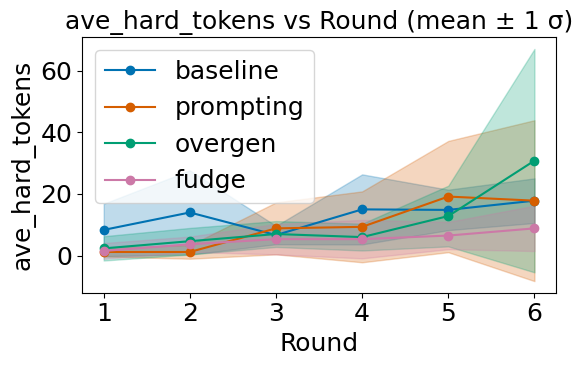

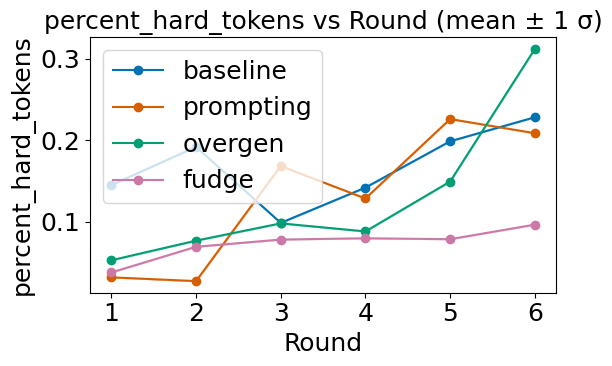

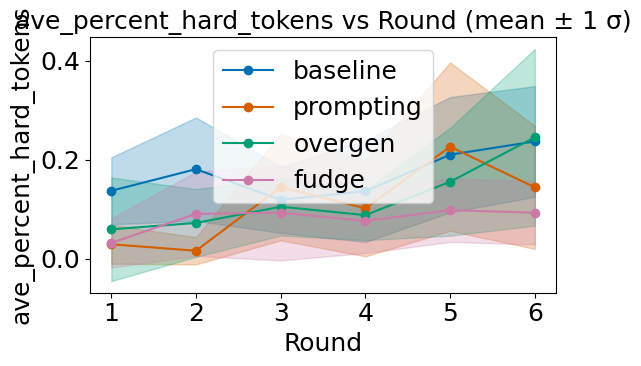

In [ ]:
# ============================================================
#  Mean ± 1 σ curves for every metric -------------------------
# ============================================================
import os, json, numpy as np, matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1)  COLLECT **per-conversation** statistics for every engine/round
# ------------------------------------------------------------------
round_data = {}                     # engine → round → accumulator-dict

for file in os.listdir(LOG_DIR):
    if not file.endswith(".json"):
        continue
    with open(os.path.join(LOG_DIR, file), encoding="utf-8") as f:
        data = json.load(f)

    engine = data.get("engine", "unknown")

    for rnd in data.get("script", []):
        if rnd.get("error", "").lower() == "major":
            continue
        r_no = rnd.get("round")
        if r_no is None:
            continue

        # ---------------- base numbers for *this* conversation & round
        understood  = rnd.get("understood", False)
        tot_tokens  = len(rnd.get("student_tokens", [])) + len(rnd.get("tutor_tokens", []))
        hard_tokens = len(rnd.get("hard_tokens", []))
        ratio       = hard_tokens / tot_tokens if tot_tokens else 0

        acc = round_data\
              .setdefault(engine, {})\
              .setdefault(r_no,
                          {                         # initialise once
                              "tok_sum": 0,         # <<< NEW >>>
                              "hard_sum": 0,        # <<< NEW >>>
                              "ratios":  [],        # <<< NEW >>>
                              "not_under": [],      # <<< NEW >>>
                              "num_tokens": [],     # <<< NEW >>>
                              "hard_tokens": []     # <<< NEW >>>
                          })

        acc["tok_sum"]      += tot_tokens           # <<< NEW >>>
        acc["hard_sum"]     += hard_tokens          # <<< NEW >>>
        acc["ratios"].append(ratio)                 # <<< NEW >>>
        acc["not_under"].append(0 if understood else 1)   # <<< NEW >>>
        acc["num_tokens"].append(tot_tokens)        # <<< NEW >>>
        acc["hard_tokens"].append(hard_tokens)      # <<< NEW >>>

# -------------------------------------------------------------
# 2)  BUILD  round_values  in the exact shape the plotting loop
#     expects, but with the *correct* definitions:
#       • percent_hard_tokens      =  Σhard / Σtokens
#       • ave_percent_hard_tokens  =  mean( hard/tokens per conversation )
# -------------------------------------------------------------
METRICS = [                                            # ensure order
    "percent_not_understood",
    "ave_num_tokens",
    "ave_hard_tokens",
    "percent_hard_tokens",
    "ave_percent_hard_tokens"
]

round_values = {}                                      # engine → metric → round → list

for eng, eng_rounds in round_data.items():
    for r_no, acc in eng_rounds.items():
        # --- collective (across conversations) ------------
        pct_hard_tokens = (acc["hard_sum"] / acc["tok_sum"]
                           if acc["tok_sum"] else 0)   # <<< CHANGED >>>
        ave_pct_hard    = np.mean(acc["ratios"])       # <<< NEW >>>

        # --- fill master dict -----------------------------
        def save(metric, value_list):
            md = round_values.setdefault(eng, {}).setdefault(metric, {})
            md[r_no] = value_list

        save("percent_not_understood",  acc["not_under"])
        save("ave_num_tokens",           acc["num_tokens"])
        save("ave_hard_tokens",          acc["hard_tokens"])
        save("percent_hard_tokens",     [pct_hard_tokens])  # single value
        save("ave_percent_hard_tokens",  acc["ratios"])

# all rounds present across engines
ROUNDS = sorted({r for eng in round_values.values()
                   for m in eng.values() for r in m})

# ------------------------------------------------------------------
# 3)  PLOT  (mean line ± 1 σ band) ---------------------------------
# ------------------------------------------------------------------
for metric in METRICS:
    plt.figure(figsize=(6, 4))
    for eng, col in color_map.items():
        r_means, r_stds = [], []
        for r in ROUNDS:
            vals = round_values.get(eng, {}).get(metric, {}).get(r, [])
            r_means.append(np.nan if not vals else np.mean(vals))
            r_stds.append(0        if not vals else np.std(vals))

        plt.plot(ROUNDS, r_means, marker="o", color=col, label=eng)
        plt.fill_between(ROUNDS,
                         np.array(r_means) - np.array(r_stds),
                         np.array(r_means) + np.array(r_stds),
                         color=col, alpha=0.25)

    plt.xlabel("Round")
    plt.ylabel(metric)
    plt.title(f"{metric} vs Round (mean ± 1 σ)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"{metric}_by_round.png"), dpi=300)
    plt.show()


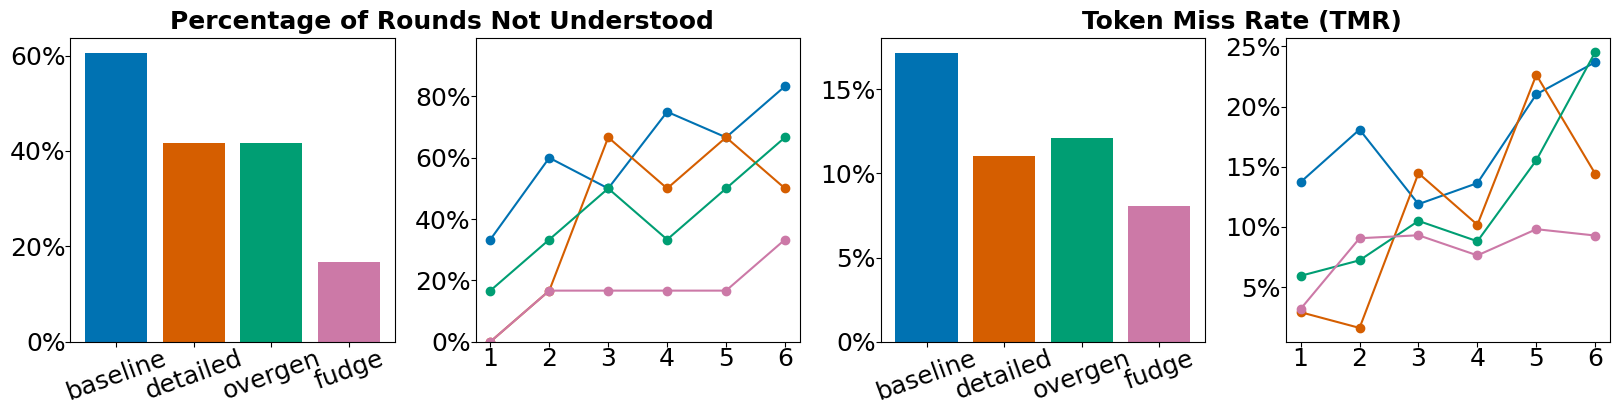

Saved 4-panel figure to: /content/drive/MyDrive/user_study_logs/percent_metrics_4panel.pdf


In [ ]:
import os, json, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

LOG_DIR = "/content/drive/MyDrive/user_study_logs"
OUT_DIR  = "/content/drive/MyDrive/user_study_logs"

FONT_SIZE = 18
FONT_SIZE_TITLE = 18

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE
})

# ABBR = {
#     "baseline":  "Bas.",
#     "prompting": "Det.",
#     "overgen":   "Ove.",
#     "fudge":     "Fud."
# }

ABBR = {
    "baseline":  "baseline",
    "prompting": "detailed",
    "overgen":   "overgen",
    "fudge":     "fudge"
}

engines = [e for e in ENGINE_ORDER if e in engine_level_summary]
bar_notU = [engine_level_summary[e]["_TOTAL"]["percent_not_understood"]*100 for e in engines]
bar_hard = [engine_level_summary[e]["_TOTAL"]["ave_percent_hard_tokens"]*100   for e in engines]


def mean_std(metric):
    m, s = {}, {}
    for eng in engines:
        mlist, slist = [], []
        for r in ROUNDS:
            vals = round_values.get(eng, {}).get(metric, {}).get(r, [])
            mlist.append(np.mean(vals)*100 if vals else np.nan)
            slist.append(np.std(vals)*100  if vals else 0)
        m[eng], s[eng] = mlist, slist
    return m, s

line_notU_m, line_notU_s = mean_std("percent_not_understood")
line_hard_m, line_hard_s = mean_std("ave_percent_hard_tokens")


fig, axes = plt.subplots(1, 4, figsize=(16, 4))

ax1, ax2, ax3, ax4 = axes

# 1 ─ bar: percent not understood
ax1.bar(engines, bar_notU, color=[color_map[e] for e in engines])

# 2 ─ line: percent not understood
for eng in engines:
    m = np.array(line_notU_m[eng])
    ax2.plot(ROUNDS, m, marker="o", color=color_map[eng])

max_notu = max(np.nanmax(np.array(line_notU_m[e]) + np.array(line_notU_s[e]))
               for e in engines)
if max_notu > 100:
    ax2.set_ylim(0, 100)
ax2.set_ylim(0, 99)


# 3 ─ bar: percent hard tokens
ax3.bar(engines, bar_hard, color=[color_map[e] for e in engines])

# 4 ─ line: percent hard tokens
for eng in engines:
    m = np.array(line_hard_m[eng])
    ax4.plot(ROUNDS, m, marker="o", color=color_map[eng])

max_hard = max(np.nanmax(np.array(line_hard_m[e]) + np.array(line_hard_s[e]))
               for e in engines)
if max_hard > 100:
    ax4.set_ylim(0, 100)

for ax in [ax1, ax3]:                      # bar charts
    ax.set_xticks(range(len(engines)))
    ax.set_xticklabels([ABBR[e] for e in engines], rotation=20)

for ax in [ax2, ax4]:                      # line charts
    ax.set_xticks(ROUNDS)
    ax.set_xticklabels(ROUNDS, rotation=0)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

percent_fmt = FuncFormatter(lambda y, _: f"{y:.0f}%")
for ax in axes:
    ax.yaxis.set_major_formatter(percent_fmt)
    ax.tick_params(axis="y", pad=0)
    ax.tick_params(axis="x", pad=0)

fig.text(0.27, 1.02, "Percentage of Rounds Not Understood", ha="center",
         fontsize=FONT_SIZE_TITLE, weight="bold")
fig.text(0.77, 1.02, "Token Miss Rate (TMR)",   ha="center",
         fontsize=FONT_SIZE_TITLE, weight="bold")

# plt.figsize?
fig.tight_layout(pad=0, rect=[0, 0.08, 1, 1])
fig.subplots_adjust(wspace=0.25)

pdf_path = os.path.join(OUT_DIR, "percent_metrics_4panel.pdf")
fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

print("Saved 4-panel figure to:", pdf_path)



=== AVERAGE LIKERT SCORES BY ENGINE ===
{
  "prompting": {
    "likert_understand": 5.5,
    "likert_effort": 5.0,
    "likert_comfort": 8.0,
    "likert_natural": 6.5,
    "likert_again": 7.333333333333333
  },
  "baseline": {
    "likert_understand": 5.166666666666667,
    "likert_effort": 5.166666666666667,
    "likert_comfort": 7.333333333333333,
    "likert_natural": 5.666666666666667,
    "likert_again": 7.333333333333333
  },
  "fudge": {
    "likert_understand": 7.666666666666667,
    "likert_effort": 4.666666666666667,
    "likert_comfort": 6.833333333333333,
    "likert_natural": 7.333333333333333,
    "likert_again": 7.666666666666667
  },
  "overgen": {
    "likert_understand": 6.333333333333333,
    "likert_effort": 5.833333333333333,
    "likert_comfort": 6.833333333333333,
    "likert_natural": 7.5,
    "likert_again": 7.333333333333333
  }
}


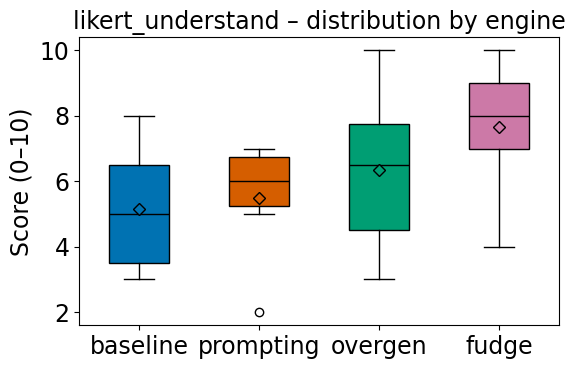

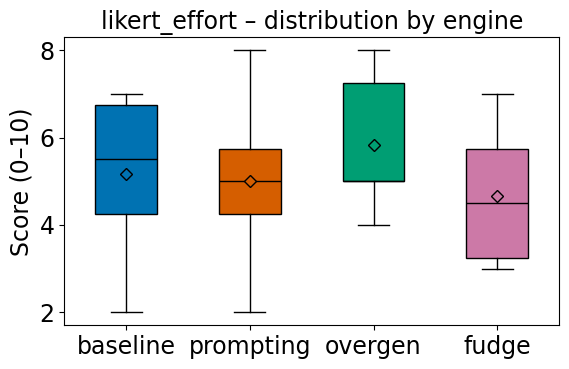

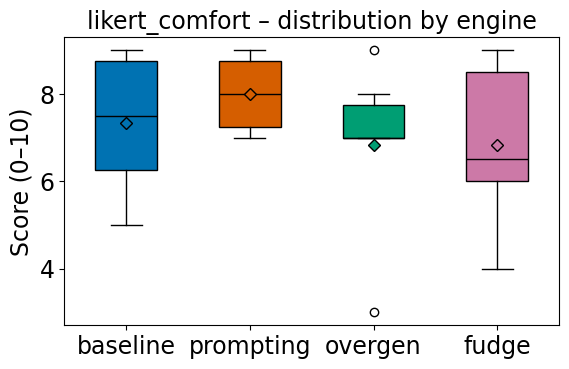

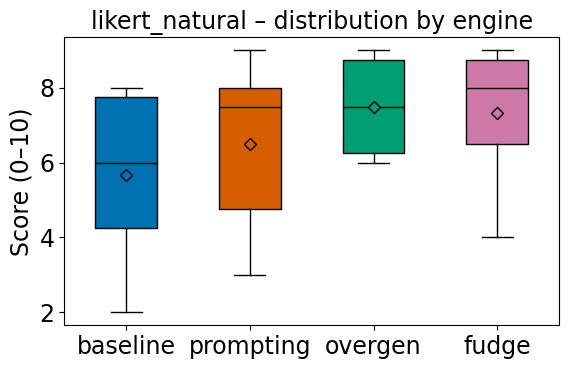

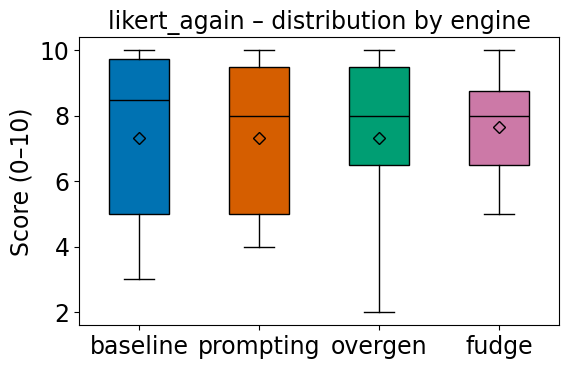

In [ ]:
# likert
import os, json, numpy as np, matplotlib.pyplot as plt

LIKERT_FIELDS = [
    "likert_understand",
    "likert_effort",
    "likert_comfort",
    "likert_natural",
    "likert_again",
]

likert_data = {}   # engine -> field -> list[values]

for file in os.listdir(LOG_DIR):
    if not file.endswith(".json"):
        continue
    data   = json.load(open(os.path.join(LOG_DIR, file), encoding="utf-8"))
    engine = data.get("engine", "unknown")
    eng    = likert_data.setdefault(engine, {f: [] for f in LIKERT_FIELDS})

    for f in LIKERT_FIELDS:
        if f in data and isinstance(data[f], (int, float)):
            eng[f].append(data[f])

# average
likert_means = {}
for eng, fields in likert_data.items():
    likert_means[eng] = {f: (np.mean(vals) if vals else 0) for f, vals in fields.items()}

import json, pprint
print("\n=== AVERAGE LIKERT SCORES BY ENGINE ===")
print(json.dumps(likert_means, ensure_ascii=False, indent=2))


for field in LIKERT_FIELDS:
    engines   = [e for e in ENGINE_ORDER if e in likert_data]
    data_sets = [likert_data[e][field] for e in engines]

    fig, ax = plt.subplots(figsize=(6, 4))

    for pos, eng, values in zip(np.arange(1, len(engines) + 1), engines, data_sets):
        meanprops = dict(marker='D',
                         markerfacecolor=color_map[eng],
                         markeredgecolor='black',
                         markersize=6)

        bp = ax.boxplot(
            [values],
            positions=[pos],
            widths=0.5,
            patch_artist=True,
            showmeans=True,
            meanprops=meanprops,
            boxprops=dict(facecolor=color_map[eng], edgecolor='black'),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='black')
        )

    ax.set_xticks(np.arange(1, len(engines) + 1))
    ax.set_xticklabels(engines)
    ax.set_ylabel("Score (0–10)")
    ax.set_title(f"{field} – distribution by engine")
    plt.tight_layout()

    pdf_path = os.path.join(OUT_DIR, f"{field}_boxplot.pdf")
    fig.savefig(pdf_path, format="pdf")
    plt.show()


<ipython-input-9-cfcf7415976a>:74: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0.5, rect=[0, 0, 1, 0.9])


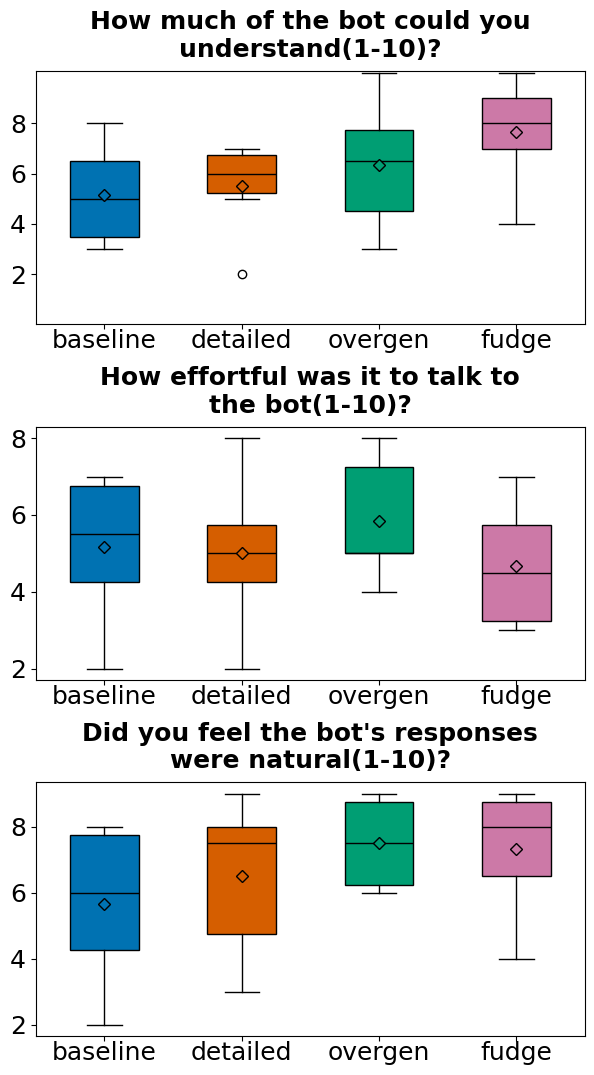

Saved 3-panel Likert figure to: /content/drive/MyDrive/user_study_logs/likert_three_boxplots.pdf


In [ ]:
import os, json, numpy as np, matplotlib.pyplot as plt
import textwrap

# wrap,
# put 1-10 at the end

FONT_SIZE = 18
FONT_SIZE_TITLE = 18

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE
})


STACK_FIELDS  = ["likert_understand", "likert_effort", "likert_natural"]
STACK_TITLES  = [
    "How much of the bot could you understand(1-10)?",
    "How effortful was it to talk to the bot(1-10)?",
    "Did you feel the bot's responses were natural(1-10)?"
    # "How much of the bot could you understand, on a scale of 1-10?",
    # "How effortful was it to talk to the bot, on a scale of 1-10?",
    # "Did you feel the bot's responses were natural, on a scale of 1-10?"
]

engines = [e for e in ENGINE_ORDER if e in likert_data]

fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(6, 12), sharey=False, constrained_layout=True
)

for ax, field, title in zip(axes, STACK_FIELDS, STACK_TITLES):
    data_sets = [likert_data[e][field] for e in engines]

    # one box per engine
    for pos, eng, values in zip(
        np.arange(1, len(engines) + 1), engines, data_sets
    ):
        meanprops = dict(
            marker="D",
            markerfacecolor=color_map[eng],
            markeredgecolor="black",
            markersize=6,
        )
        ax.boxplot(
            [values],
            positions=[pos],
            widths=0.5,
            patch_artist=True,
            showmeans=True,
            meanprops=meanprops,
            boxprops=dict(facecolor=color_map[eng], edgecolor="black"),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black"),
            medianprops=dict(color="black"),
        )

    # keep x-axis engine labels
    ax.set_xticks(np.arange(1, len(engines) + 1))
    ax.set_xticklabels([ABBR[e] for e in engines], rotation=0)
    ax.set_ylabel("")
    wrapped = "\n".join(textwrap.wrap(title, width=32))
    ax.set_title(wrapped, pad=10, fontsize=FONT_SIZE_TITLE, weight="bold")

axes[0].set_ylim(0, 10.1)
axes[0].set_yticks([2, 4, 6, 8])
for ax in axes:
    ax.tick_params(axis="x", pad=0)
# save and display
fig.tight_layout(pad=0.5, rect=[0, 0, 1, 0.9])
pdf_path = os.path.join(OUT_DIR, "likert_three_boxplots.pdf")
fig.savefig(pdf_path, format="pdf")
plt.show()

print("Saved 3-panel Likert figure to:", pdf_path)


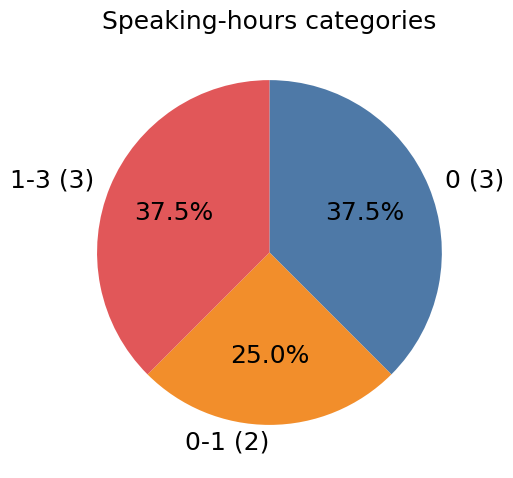

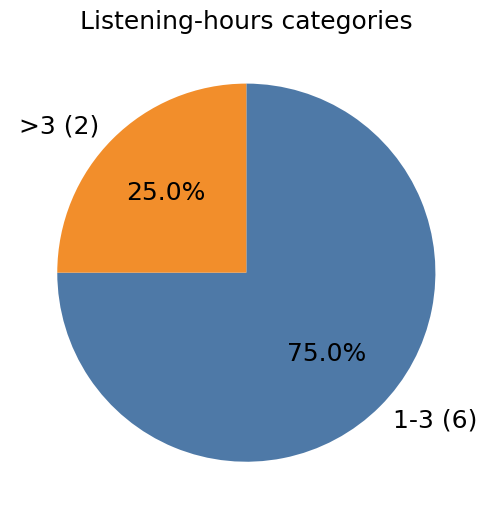

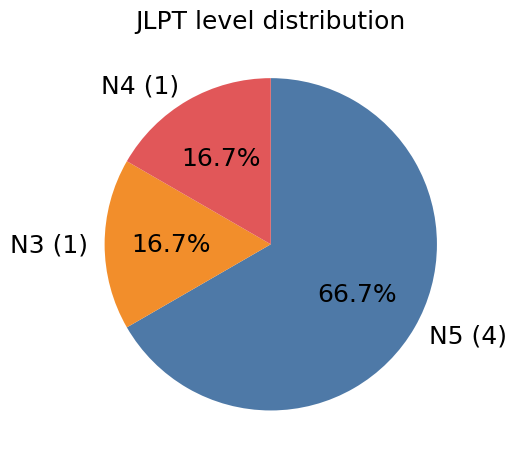

Pie charts saved to: /content/drive/MyDrive/user_study_logs


In [ ]:
import os, json, matplotlib.pyplot as plt
from collections import Counter


DEMOGRAPHICS_PATH = "/content/drive/MyDrive/demographics.json"

with open(DEMOGRAPHICS_PATH, encoding="utf-8") as f:
    demo = json.load(f)


speak_cnt  = Counter(d["speaking_category"]  for d in demo)
listen_cnt = Counter(d["listening_category"] for d in demo)
level_cnt  = Counter(d["level"]              for d in demo)
del level_cnt['N2']

#  Tableau 10 qualitative palette
#  Source: https://tableaufriction.blogspot.com/2012/11/finally-you-can-use-tableau-data-colors.html
TABLEAU10 = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2',
             '#59A14F', '#EDC948', '#B07AA1', '#FF9DA7']

def pie_chart(counter: Counter, title: str, filename: str):
    labels = list(counter.keys())
    sizes  = [counter[k] for k in labels]
    colors = TABLEAU10[:len(labels)]

    plt.figure(figsize=(5, 5))
    plt.pie(
        sizes,
        labels=[f"{lab} ({cnt})" for lab, cnt in zip(labels, sizes)],
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False
    )
    plt.title(title)
    plt.tight_layout(pad=0)
    plt.savefig(os.path.join(OUT_DIR, filename), format="pdf")
    plt.show()
    plt.close()


pie_chart(speak_cnt,
          "Speaking-hours categories",
          "speak_category_pie.pdf")

pie_chart(listen_cnt,
          "Listening-hours categories",
          "listen_category_pie.pdf")

pie_chart(level_cnt,
          "JLPT level distribution",
          "level_distribution_pie.pdf")

print("Pie charts saved to:", OUT_DIR)


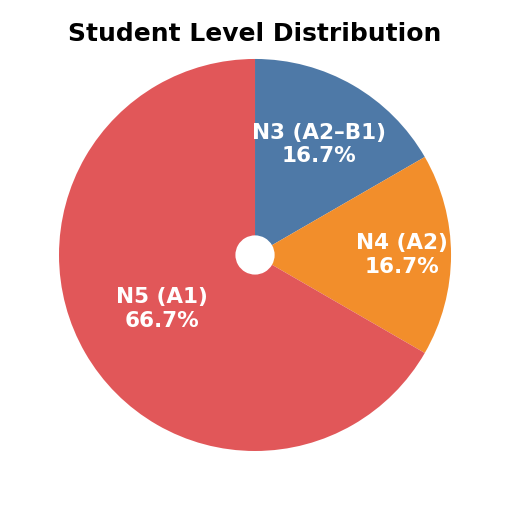

Saved JLPT pie chart to: /content/drive/MyDrive/user_study_logs/level_distribution_pie.pdf


In [ ]:
import os, json, matplotlib.pyplot as plt
from collections import Counter
import numpy as np

FONT_SIZE = 15.5

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE
})

JLPT_TO_CEFR = {
    "N5": "A1",
    "N4": "A2",
    "N3": "A2–B1",
    "N2": "B1–B2",
    "N1": "B2–C1"
}

with open(DEMOGRAPHICS_PATH, encoding="utf-8") as f:
    demo = json.load(f)

level_cnt = Counter(d["level"] for d in demo)
del level_cnt['N2']

TABLEAU10 = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2',
             '#59A14F', '#EDC948', '#B07AA1', '#FF9DA7']

levels  = sorted(level_cnt.keys(), key=lambda x: int(x[1]))
sizes   = [level_cnt[lvl] for lvl in levels]
total   = sum(sizes)
colors  = TABLEAU10[:len(levels)]
perc    = [size / total * 100 for size in sizes]
labels  = [f"{lvl} ({JLPT_TO_CEFR.get(lvl, '?')})\n{p:.1f}%" for lvl, p in zip(levels, perc)]

LABEL_OFFSET = {
    "N2": (0.6,  0),
    "N3": (0.65,  0),
    "N4": (0.75,  0),
}

fig, ax = plt.subplots(figsize=(5, 5))

wedges = ax.pie(
    sizes,
    labels=None,
    colors=colors,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.9)
)[0]

for w, lvl, lbl in zip(wedges, levels, labels):
    angle = (w.theta2 + w.theta1) / 2
    r_mult, dtheta = LABEL_OFFSET.get(lvl, (0.55, 0))
    angle += dtheta
    x = r_mult * np.cos(np.deg2rad(angle))
    y = r_mult * np.sin(np.deg2rad(angle))
    ax.text(
        x, y, lbl,
        ha="center", va="center",
        fontsize=FONT_SIZE, color="white", weight="bold"
    )

fig.subplots_adjust(top=0.5, bottom=0.4, left=0.0, right=0.98)

ax.set_aspect('equal')
plt.tight_layout(pad=0, h_pad=0, w_pad = 0)

ax.set_title("Student Level Distribution",
             fontsize=18, weight="bold", y=0.92)  # 0.97 is just above the axes box

pdf_path = os.path.join(OUT_DIR, "level_distribution_pie.pdf")
fig.savefig(pdf_path, format="pdf", bbox_inches='tight', pad_inches=0)
plt.show()

print("Saved JLPT pie chart to:", pdf_path)



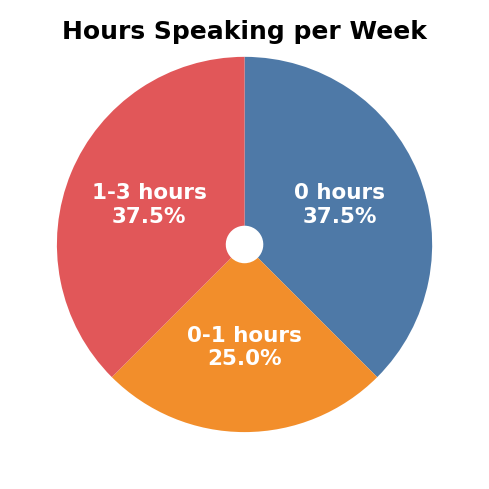

Saved speaking-hours pie chart to: /content/drive/MyDrive/user_study_logs/speaking_category_pie.pdf


In [ ]:
import os, json, matplotlib.pyplot as plt
from collections import Counter
import numpy as np

FONT_SIZE         = 15.5

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE
})

# ---------- map raw answers → 4 groups ----------
RAW_TO_GROUP = {
    "0":             "0 hours",
    "<1":            "0-1 hours",
    "0-1":           "0-1 hours",
    "1":             "0-1 hours",
    "1 hr":          "0-1 hours",
    "1 hour/wk":     "0-1 hours",
    "1-3":           "1-3 hours",
    "2":             "1-3 hours",
    "2-3":           "1-3 hours",
    "2-3 hrs":       "1-3 hours",
    "1-2 hours":     "1-3 hours",
    ">3":            ">3 hours",
    "4":             ">3 hours"
}
ORDER = ["0 hours", "0-1 hours", "1-3 hours", ">3 hours"]

with open(DEMOGRAPHICS_PATH, encoding="utf-8") as f:
    demo = json.load(f)

group_cnt = Counter(RAW_TO_GROUP.get(d["speaking_category"], "other")
                    for d in demo)

if group_cnt.get("other") == 0:
    group_cnt.pop("other", None)

groups = [g for g in ORDER if g in group_cnt]
sizes  = [group_cnt[g] for g in groups]
total  = sum(sizes)
perc   = [s / total * 100 for s in sizes]

TABLEAU10 = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2',
             '#59A14F', '#EDC948', '#B07AA1', '#FF9DA7']
colors = TABLEAU10[:len(groups)]
labels = [f"{g}\n{p:.1f}%" for g, p in zip(groups, perc)]

LABEL_OFFSET = {
    # "1-3 hours": (0.60, 2),
}

fig, ax = plt.subplots(figsize=(5, 5))

wedges = ax.pie(
    sizes, labels=None, colors=colors,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.9)
)[0]

for w, g, lbl in zip(wedges, groups, labels):
    angle = (w.theta2 + w.theta1) / 2
    r_mult, dtheta = LABEL_OFFSET.get(g, (0.55, 0))
    angle += dtheta
    x = r_mult * np.cos(np.deg2rad(angle))
    y = r_mult * np.sin(np.deg2rad(angle))
    ax.text(x, y, lbl, ha="center", va="center",
            fontsize=FONT_SIZE, color="white", weight="bold")

# enlarge axes + shrink margins
ax.set_position([0.00, 0.00, 1.00, 1.00])
fig.subplots_adjust(top=0.50, bottom=0.40, left=0.0, right=0.98)

ax.set_title("Hours Speaking per Week",
             fontsize=18, weight="bold", y=0.92)

ax.set_aspect('equal')
plt.tight_layout(pad=0, h_pad=0, w_pad=0)

pdf_path = os.path.join(OUT_DIR, "speaking_category_pie.pdf")
fig.savefig(pdf_path, format="pdf", bbox_inches='tight', pad_inches=0)
plt.show()

print("Saved speaking-hours pie chart to:", pdf_path)



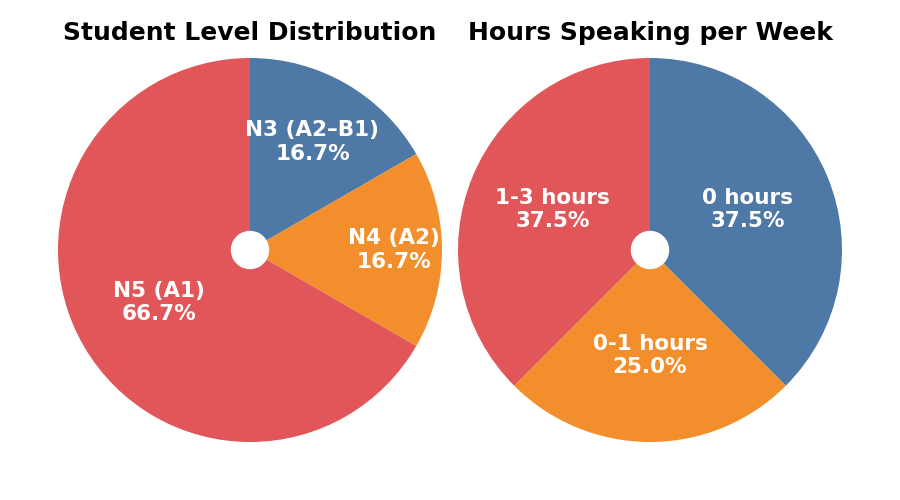

Saved side-by-side pie chart to: /content/drive/MyDrive/user_study_logs/levels_and_speaking_pies.pdf


In [ ]:
import os, json, numpy as np, matplotlib.pyplot as plt
from collections import Counter

FONT_SIZE = 15.5
plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": 18,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE
})

TABLEAU10 = ['#4E79A7', '#F28E2B', '#E15759', '#76B7B2',
             '#59A14F', '#EDC948', '#B07AA1', '#FF9DA7']

with open(DEMOGRAPHICS_PATH, encoding="utf-8") as f:
    demo = json.load(f)


JLPT_TO_CEFR = {"N5":"A1","N4":"A2","N3":"A2–B1","N2":"B1–B2","N1":"B2–C1"}
level_cnt    = Counter(d["level"] for d in demo)
del level_cnt['N2']
levels       = sorted(level_cnt, key=lambda x:int(x[1]))  # N1..N5 order
level_sizes  = [level_cnt[lvl] for lvl in levels]
level_perc   = [s/sum(level_sizes)*100 for s in level_sizes]
level_labels = [f"{lvl} ({JLPT_TO_CEFR[lvl]})\n{p:.1f}%" for lvl,p in zip(levels,level_perc)]

LEVEL_OFFSET = {"N2":(0.60,0), "N3":(0.65,0), "N4":(0.75,0)}

RAW_TO_GROUP = {
    "0":"0 hours", "<1":"0-1 hours", "0-1":"0-1 hours",
    "1":"0-1 hours","1 hr":"0-1 hours","1 hour/wk":"0-1 hours",
    "1-3":"1-3 hours","2":"1-3 hours","2-3":"1-3 hours",
    "2-3 hrs":"1-3 hours","1-2 hours":"1-3 hours",
    ">3":">3 hours","4":">3 hours"
}
GROUP_ORDER   = ["0 hours","0-1 hours","1-3 hours",">3 hours"]
speak_cnt     = Counter(RAW_TO_GROUP.get(d["speaking_category"],"other") for d in demo)
if speak_cnt.get("other") == 0: speak_cnt.pop("other",None)
groups        = [g for g in GROUP_ORDER if g in speak_cnt]
speak_sizes   = [speak_cnt[g] for g in groups]
speak_perc    = [s/sum(speak_sizes)*100 for s in speak_sizes]
speak_labels  = [f"{g}\n{p:.1f}%" for g,p in zip(groups,speak_perc)]

SPEAK_OFFSET  = {}


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ---------------- JLPT pie ----------------
ax = axes[0]
wedges = ax.pie(level_sizes, labels=None, colors=TABLEAU10[:len(levels)],
                startangle=90, counterclock=False, wedgeprops=dict(width=0.9))[0]

for w,lbl,lvl in zip(wedges,level_labels,levels):
    ang = (w.theta2+w.theta1)/2
    r,a = LEVEL_OFFSET.get(lvl,(0.55,0))
    ang += a
    ax.text(r*np.cos(np.deg2rad(ang)), r*np.sin(np.deg2rad(ang)),
            lbl, ha="center", va="center", color="white", weight="bold")

ax.set_title("Student Level Distribution", y=0.92, weight="bold")
ax.set_aspect('equal')
axes[0].set_position([0.00, 0.02, 0.50, 0.96])

# ---------------- Speaking-hours pie ----------------
ax = axes[1]
wedges = ax.pie(speak_sizes, labels=None, colors=TABLEAU10[:len(groups)],
                startangle=90, counterclock=False, wedgeprops=dict(width=0.9))[0]

for w,lbl,g in zip(wedges,speak_labels,groups):
    ang = (w.theta2+w.theta1)/2
    r,a = SPEAK_OFFSET.get(g,(0.55,0))
    ang += a
    ax.text(r*np.cos(np.deg2rad(ang)), r*np.sin(np.deg2rad(ang)),
            lbl, ha="center", va="center", color="white", weight="bold")

ax.set_title("Hours Speaking per Week", y=0.92, weight="bold")
ax.set_aspect('equal')
axes[1].set_position([0.4, 0.02, 0.50, 0.96])

#  tight save
pdf_path = os.path.join(OUT_DIR, "levels_and_speaking_pies.pdf")
fig.savefig(pdf_path, format="pdf", bbox_inches='tight', pad_inches=0)
plt.show()
print("Saved side-by-side pie chart to:", pdf_path)


=== ENGINE / LEVEL SUMMARY ===
{
  "baseline_gpt": {
    "error_cnt_major": 0,
    "error_cnt_minor": 0,
    "_TOTAL": {
      "percent_hard_tokens": 0.5449607900087133,
      "ave_percent_hard_tokens": 0.4761513070623559
    },
    "n5": {
      "percent_hard_tokens": 0.5449607900087133,
      "ave_percent_hard_tokens": 0.4761513070623559
    }
  },
  "baseline_qwen": {
    "error_cnt_major": 0,
    "error_cnt_minor": 0,
    "_TOTAL": {
      "percent_hard_tokens": 0.5756207674943566,
      "ave_percent_hard_tokens": 0.4647382031517413
    },
    "n5": {
      "percent_hard_tokens": 0.5756207674943566,
      "ave_percent_hard_tokens": 0.4647382031517413
    }
  },
  "fudge_0.5": {
    "error_cnt_major": 0,
    "error_cnt_minor": 0,
    "_TOTAL": {
      "percent_hard_tokens": 0.5407760701878349,
      "ave_percent_hard_tokens": 0.47158321365266015
    },
    "n5": {
      "percent_hard_tokens": 0.5407760701878349,
      "ave_percent_hard_tokens": 0.47158321365266015
    }
  },
  "fudg

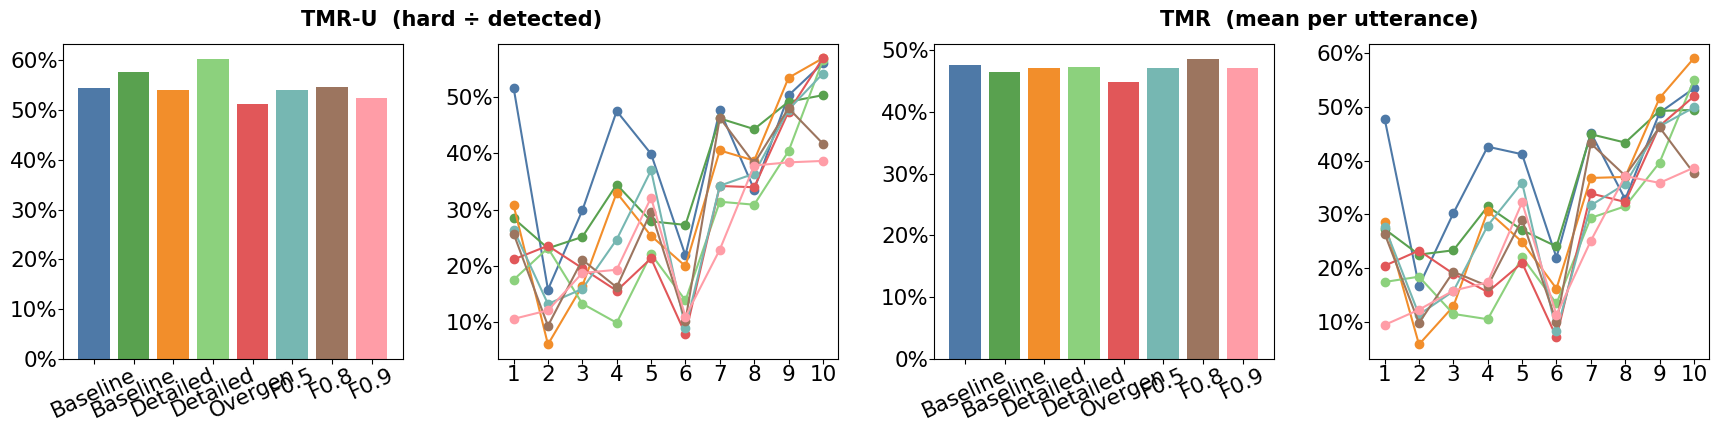

In [ ]:


LOG_DIR = "/content/drive/MyDrive/conversation_logs"
OUT_DIR  = "/content/drive/MyDrive/conversation_logs"

# ============================================================
# 0.  CONFIG --------------------------------------------------
# ============================================================
import os, re, json, itertools, collections, numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# plotting order you prefer — extend / reorder freely
ENGINE_ORDER = [            # list only engines that really exist
    "baseline_gpt", "baseline_qwen",
    "detailed_gpt", "detailed_qwen",
    "overgen_gpt",                 # ← only GPT for overgen
    "fudge_0.25", "fudge_0.5", "fudge_0.8", "fudge_0.9"
]
ROUNDS = list(range(1, 11))
COLOR  = ['#4E79A7','#59A14F','#F28E2B','#8CD17D','#E15759',
          '#B6992D','#76B7B2','#9C755F','#FF9DA7','#EDC948']  # grow if needed
COLOR_MAP = {eng:c for eng,c in zip(ENGINE_ORDER,COLOR)}

ABBR = {e: e.split('_')[0].capitalize() if 'fudge' not in e
        else f"F{e.split('_')[1]}" for e in ENGINE_ORDER}

JLPT_RANK = {"n1":1,"n2":2,"n3":3,"n4":4,"n5":5}

# helpers -----------------------------------------------------
def engine_key(fname, data):
    """
    Map a log file → canonical engine name.
    Keeps fudge logs separate by λ value (e.g. “fudge_0.5”).
    Ignores any file that doesn’t belong to our set.
    """
    fname_lower = fname.lower()

    # 1) technique ---------------------------------------------------
    if   "baseline" in fname_lower: base = "baseline"
    elif "detailed" in fname_lower: base = "detailed"
    elif "overgen"  in fname_lower: base = "overgen"
    elif "fudge"    in fname_lower:
        m = re.search(r"lambda[=_]?([\d.]+)", fname_lower)
        if not m:
            return None                      # ← malformed; skip
        lam = m.group(1).rstrip(".")         #   <<< strip trailing dot
        base = f"fudge_{lam}"
        # fudge has no GPT/Qwen split – treat each λ as its own engine
        return base
    else:
        return None                          #   anything else ⇒ skip

    # 2) model --------------------------------------------------------
    mdl = data.get("tutor_model_id", "").lower()
    model = "gpt"  if "gpt"  in mdl else \
            "qwen" if "qwen" in mdl else None
    if model is None:
        return None                          # unknown → skip

    return f"{base}_{model}"

def new_stats():
    return dict(rounds=0,
                detected=0, hard=0,
                per_utt=[])

def add(stat, hard, det, ratio):
    stat["rounds"]   += 1
    stat["detected"] += det
    stat["hard"]     += hard
    stat["per_utt"].append(ratio)

def finalise(stat):
    if stat["detected"]==0:
        return {"percent_hard_tokens":0, "ave_percent_hard_tokens":0}
    return {
        "percent_hard_tokens": stat["hard"]/stat["detected"],
        "ave_percent_hard_tokens": float(np.mean(stat["per_utt"]))
    }

# containers --------------------------------------------------
engine_level_summary = {}          # engine → level/“_TOTAL” → metrics
engine_round_summary = {}          # engine → round → metrics
round_values         = collections.defaultdict(
                        lambda: collections.defaultdict(
                          lambda: collections.defaultdict(list)))

# ============================================================
# 1.  WALK THROUGH LOGS --------------------------------------
# ============================================================
for fname in os.listdir(LOG_DIR):
    if not fname.endswith(".json"): continue
    with open(os.path.join(LOG_DIR,fname),encoding="utf-8") as f:
        data = json.load(f)

    eng = engine_key(fname, data)
    tutor_level = data["conversations"][0]["tutor_level"].lower()
    level_rank  = JLPT_RANK[tutor_level]

    e_map = engine_level_summary.setdefault(
              eng, {"error_cnt_major":0,"error_cnt_minor":0,"_TOTAL":new_stats()})
    e_map.setdefault(tutor_level, new_stats())
    r_map = engine_round_summary.setdefault(eng, {})

    for r_no, conv in enumerate(data["conversations"], start=1):
        det_round, hard_round, per_utt = 0,0,[]

        for turn in conv["script"]:
            det_counts = turn["jlpt_anki_with_reading_detected_counts"]
            det = sum(det_counts.values())
            if det==0: continue

            hard = sum(cnt for lvl,cnt in det_counts.items()
                        if JLPT_RANK[lvl] < level_rank)  # strictly higher
            det_round  += det
            hard_round += hard
            per_utt.append(hard/det)

        if det_round==0:                            # nothing in this round
            continue

        ratio_round = hard_round/det_round
        # add to level + total
        add(e_map[tutor_level], hard_round, det_round, ratio_round)
        add(e_map["_TOTAL"],    hard_round, det_round, ratio_round)

        # per-round bucket
        stats = r_map.setdefault(r_no, new_stats())
        add(stats, hard_round, det_round, ratio_round)

        round_values[eng]["percent_hard_tokens"][r_no].append(ratio_round)
        round_values[eng]["ave_percent_hard_tokens"][r_no].append(np.mean(per_utt))

# finalise dictionaries --------------------------------------
for eng,d in engine_level_summary.items():
    for k in list(d.keys()):
        if isinstance(d[k],dict) and "detected" in d[k]:
            d[k] = finalise(d[k])
for eng,d in engine_round_summary.items():
    for r in d:
        d[r] = finalise(d[r])

print("=== ENGINE / LEVEL SUMMARY ===")
print(json.dumps(engine_level_summary, indent=2, ensure_ascii=False))

print("\n=== ENGINE / ROUND SUMMARY ===")
print(json.dumps(engine_round_summary, indent=2, ensure_ascii=False))

# ============================================================
# 2.  PLOT 4-PANEL FIG ---------------------------------------
# ============================================================
FONT = dict(size=15)
plt.rcParams.update({"font.size":15})

engines = [e for e in ENGINE_ORDER if e in engine_level_summary]
bar_tmrU = [engine_level_summary[e]["_TOTAL"]["percent_hard_tokens"]*100
            for e in engines]
bar_tmr  = [engine_level_summary[e]["_TOTAL"]["ave_percent_hard_tokens"]*100
            for e in engines]

def collect(metric):
    mean={}; std={}
    for e in engines:
        m=[]; s=[]
        for r in ROUNDS:
            vals = round_values[e][metric].get(r, [])
            m.append(np.nan if not vals else np.mean(vals)*100)
            s.append(0     if not vals else np.std(vals)*100)
        mean[e], std[e] = m, s
    return mean,std

mean_tmrU,_ = collect("percent_hard_tokens")
mean_tmr ,_ = collect("ave_percent_hard_tokens")

fig,(ax1,ax2,ax3,ax4)=plt.subplots(1,4,figsize=(17,4))

# bars --------------------------------------------------------
ax1.bar(range(len(engines)), bar_tmrU, color=[COLOR_MAP[e] for e in engines])
ax3.bar(range(len(engines)), bar_tmr , color=[COLOR_MAP[e] for e in engines])

# lines -------------------------------------------------------
for e in engines:
    ax2.plot(ROUNDS, mean_tmrU[e], marker='o', color=COLOR_MAP[e])
    ax4.plot(ROUNDS, mean_tmr [e], marker='o', color=COLOR_MAP[e])

# cosmetics ---------------------------------------------------
for a in (ax1,ax3):
    a.set_xticks(range(len(engines)))
    a.set_xticklabels([ABBR[e] for e in engines], rotation=25)
for a in (ax2,ax4):
    a.set_xticks(ROUNDS); a.set_xticklabels(ROUNDS)

fmt = FuncFormatter(lambda y,_:f"{y:.0f}%")
for a in (ax1,ax2,ax3,ax4):
    a.yaxis.set_major_formatter(fmt)
    a.tick_params(axis='x', pad=1); a.tick_params(axis='y', pad=0)

fig.text(0.26,1.04,"TMR-U  (hard ÷ detected)",ha='center',weight='bold')
fig.text(0.77,1.04,"TMR  (mean per utterance)",ha='center',weight='bold')

fig.tight_layout(pad=0, rect=[0,0.05,1,1])
fig.subplots_adjust(wspace=0.28)

out = os.path.join(OUT_DIR,"tmr_metrics_4panel_correct.pdf")
fig.savefig(out, dpi=300, bbox_inches="tight")
print("\nSaved figure ->",out)
plt.show()


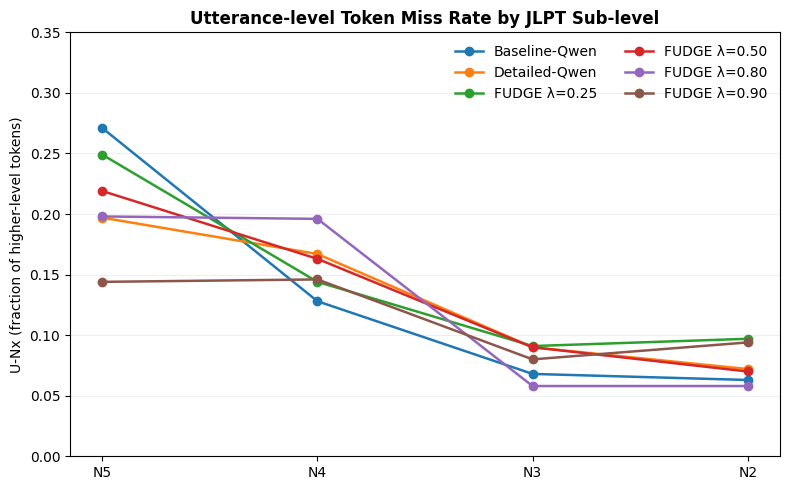

In [ ]:
# ------------------------------------------------------------
#  Plot U-Nx metrics for Qwen-based engines (+ all FUDGE λ)
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline   # cubic spline

# ---------- hard-coded numbers from your table --------------
levels   = ["N5", "N4", "N3", "N2"]
x_idx    = np.arange(len(levels))

data = {
    "Baseline-Qwen" : [0.271, 0.128, 0.068, 0.063],
    "Detailed-Qwen" : [0.197, 0.167, 0.090, 0.072],
    "FUDGE λ=0.25"  : [0.249, 0.144, 0.091, 0.097],
    "FUDGE λ=0.50"  : [0.219, 0.163, 0.090, 0.070],
    "FUDGE λ=0.80"  : [0.198, 0.196, 0.058, 0.058],
    "FUDGE λ=0.90"  : [0.144, 0.146, 0.080, 0.094],
}

# one distinct colour per engine -----------------------------
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']   # default palette
color_map = {name: colors[i % len(colors)]                   # recycle if >10
             for i, name in enumerate(data)}

# ---------- plot --------------------------------------------
plt.figure(figsize=(8, 5))

for name, y in data.items():
    col = color_map[name]

    # raw line + markers
    plt.plot(x_idx, y, marker='o', linewidth=1.8, color=col, label=name)

# ---------- cosmetics ---------------------------------------
plt.xticks(x_idx, levels)
plt.ylabel("U-Nx (fraction of higher-level tokens)")
plt.ylim(0, 0.35)
plt.title("Utterance-level Token Miss Rate by JLPT Sub-level", weight='bold')
plt.legend(frameon=False, ncol=2)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()

plt.show()


<ipython-input-3-22abda1a479f>:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, ncol=2)


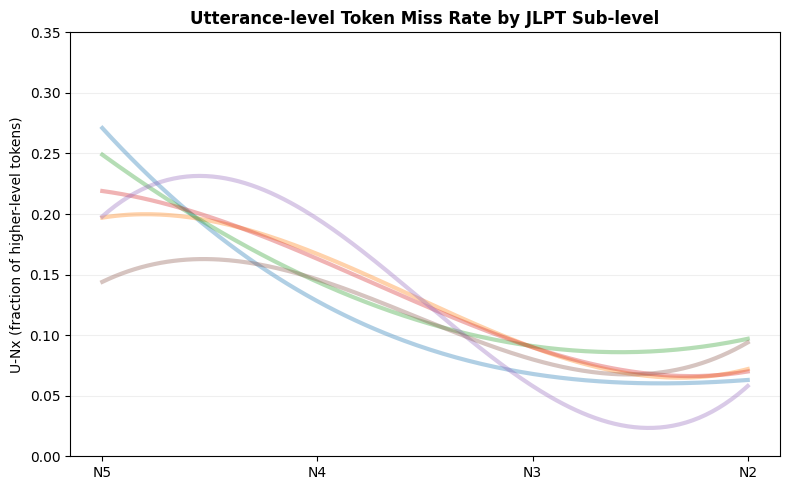

In [ ]:
# ------------------------------------------------------------
#  Plot U-Nx metrics for Qwen-based engines (+ all FUDGE λ)
# ------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline   # cubic spline

# ---------- hard-coded numbers from your table --------------
levels   = ["N5", "N4", "N3", "N2"]
x_idx    = np.arange(len(levels))

data = {
    "Baseline-Qwen" : [0.271, 0.128, 0.068, 0.063],
    "Detailed-Qwen" : [0.197, 0.167, 0.090, 0.072],
    "FUDGE λ=0.25"  : [0.249, 0.144, 0.091, 0.097],
    "FUDGE λ=0.50"  : [0.219, 0.163, 0.090, 0.070],
    "FUDGE λ=0.80"  : [0.198, 0.196, 0.058, 0.058],
    "FUDGE λ=0.90"  : [0.144, 0.146, 0.080, 0.094],
}

# one distinct colour per engine -----------------------------
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']   # default palette
color_map = {name: colors[i % len(colors)]                   # recycle if >10
             for i, name in enumerate(data)}

# ---------- plot --------------------------------------------
plt.figure(figsize=(8, 5))

for name, y in data.items():
    col = color_map[name]


    # smoothed curve (cubic spline through the 4 points)
    xs_dense = np.linspace(x_idx.min(), x_idx.max(), 200)
    ys_smooth = make_interp_spline(x_idx, y, k=3)(xs_dense)
    plt.plot(xs_dense, ys_smooth, color=col, alpha=0.35, linewidth=3)

# ---------- cosmetics ---------------------------------------
plt.xticks(x_idx, levels)
plt.ylabel("U-Nx (fraction of higher-level tokens)")
plt.ylim(0, 0.35)
plt.title("Utterance-level Token Miss Rate by JLPT Sub-level", weight='bold')
plt.legend(frameon=False, ncol=2)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()

plt.show()


